In [1]:
import pandas as pd
import random
import numpy as np
np.float_ = np.float64
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from danrerlib import mapping, utils


data_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/Lawson_map_combined/all-sample/DGE_filtered/'
out_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/Pseudobulk/'

In [2]:
import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [3]:
adata = sc.read(data_path + 'labelled.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 82724 × 31148
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', '_scvi_batch', '_scvi_labels', 'doublet_x', 'singlet_x', 'prediction_x', 'doublet_y', 'singlet_y', 'prediction_y', 'genotype', 'batch', 'ref5_label', 'ref5_score', 'ref10_label', 'ref10_score', 'predicted', 'transfer_score', 'overcluster', 'ref_label', 'CellType', 'CellTypeMajor'
    var: 'gene_id', 'genome', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'CellTypeMajor_colors', 'CellType_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'overcluster_colors', 'pca', 'predicted_col

## DGE for one cell type

In [5]:
#cell_subset = adata[adata.obs["CellTypeMajor"] == "Neural"]

In [6]:
#example WITH pseudo replicates
#pbs = []
#for sample in cell_subset.obs['sample'].unique():
   # samp_cell_subset = cell_subset[cell_subset.obs['sample'] == sample]
    
   # samp_cell_subset.X = samp_cell_subset.layers['counts'] #make sure to use raw data
    
    
    
   # indices = list(samp_cell_subset.obs_names)
   # random.shuffle(indices)
   # indices = np.array_split(np.array(indices), 2) #change number here for number of replicates deisred
    
   # for i, pseudo_rep in enumerate(indices):
    
       # rep_adata = sc.AnnData(X = samp_cell_subset[indices[i]].X.sum(axis = 0),
               #                var = samp_cell_subset[indices[i]].var[[]])

       # rep_adata.obs_names = [sample + '_' + str(i)]
      #  rep_adata.obs['sample'] = samp_cell_subset.obs['sample'].iloc[0]
      #  rep_adata.obs['replicate'] = i

      #  pbs.append(rep_adata)

In [7]:
#pb = sc.concat(pbs)

In [8]:
#pb.obs

In [9]:
#counts = pd.DataFrame(pb.X, columns = pb.var_names) #need to do this to pass var names

In [10]:
#dds = DeseqDataSet(
 #   counts = counts,
  #  metadata =pb.obs,
  #  design_factors="genotype")

In [11]:
#sc.pp.filter_genes(dds, min_cells = 1)

In [12]:
#dds.deseq2()

In [13]:
#sc.tl.pca(dds)
#sc.pl.pca(dds, color = 'genotype', size = 200)

In [14]:
# contrasting 
#stat_res = DeseqStats(dds, contrast=('genotype', 'S2b', 'Wik'))
#stat_res.summary()
#de  = stat_res.results_df
#de.sort_values('stat', ascending = False)
#de.to_csv(out_path +'deg_neurons_s2b.csv', index=True)

## DGE through a loop

In [15]:
#setup to contrast major cell types through loop
celltypes= adata.obs.CellTypeMajor.unique()
cont = ['genotype','S2b','Wik']

In [16]:
# contrasting loop, change genotype and set cell types above then set names

for celltype in celltypes:

    cell_subset = adata[adata.obs["CellTypeMajor"] == celltype]
    pbs = []
    for sample in cell_subset.obs['sample'].unique():
        samp_cell_subset = cell_subset[cell_subset.obs['sample'] == sample]
        samp_cell_subset.X = samp_cell_subset.layers['counts'] #make sure to use raw data
        indices = list(samp_cell_subset.obs_names)
        random.shuffle(indices)
        indices = np.array_split(np.array(indices), 2) #change number here for number of replicates deisred
    
        for i, pseudo_rep in enumerate(indices):
            rep_adata = sc.AnnData(X = samp_cell_subset[indices[i]].X.sum(axis = 0),
                               var = samp_cell_subset[indices[i]].var[[]])
            rep_adata.obs_names = [sample + '_' + str(i)]
            rep_adata.obs['sample'] = samp_cell_subset.obs['sample'].iloc[0]
            rep_adata.obs['replicate'] = i

            pbs.append(rep_adata)
    pb = sc.concat(pbs)
    split = pb.obs['sample'].str.split('-', expand=True).rename(columns={0:'genotype', 1:'batch'})
    pb.obs['genotype'] = split.genotype
    pb.obs['batch'] = split.batch
    counts = pd.DataFrame(pb.X, columns = pb.var_names)
    dds = DeseqDataSet(
        counts = counts,
        metadata =pb.obs,
        design_factors="genotype")
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=(cont)) # set the genotype here
    stat_res.summary()
    de  = stat_res.results_df
    de.to_csv(out_path +'deg_' +celltype+'_s2b.csv', index=True)

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.09 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 1.39 seconds.

Fitting LFCs...
... done in 1.15 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.80 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf          0.681330       -1.521193  1.741240 -0.873626  0.382322       NaN
a2ml          0.528735       -0.726473  1.835591 -0.395770  0.692274       NaN
aaas          6.061576       -0.183746  0.618198 -0.297228  0.766292  0.965109
aacs        101.191178       -0.465231  0.160454 -2.899463  0.003738  0.173501
aadac         2.402043       -0.486479  0.940639 -0.517180  0.605031       NaN
...                ...             ...       ...       ...       ...       ...
CR450808.4    0.033358        0.441138  4.746524  0.092939  0.925952       NaN
zgc:153137    0.000000             NaN       NaN       NaN       NaN       NaN
echdc1        1.104626        1.128506  1.294555  0.871733  0.383354       NaN
sipa1l2-1    75.554593        0.178950  0.195176  0.916866  0.359213  0.873425
eme2          0.573279        0.141234  1.742157  0.081068  0.935388     

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.37 seconds.

Fitting dispersion trend curve...
... done in 0.32 seconds.

Fitting MAP dispersions...
... done in 1.53 seconds.

Fitting LFCs...
... done in 1.27 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.71 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf          3.917195        3.887211  1.554130  2.501213  0.012377  0.380830
a2ml          0.703181        1.114108  2.561409  0.434959  0.663592       NaN
aaas         11.647573        0.013727  0.534879  0.025664  0.979525  0.999918
aacs        173.008588       -0.557293  0.136487 -4.083125  0.000044  0.008203
aadac         2.353667       -1.157583  0.877964 -1.318485  0.187341       NaN
...                ...             ...       ...       ...       ...       ...
CR450808.4    0.063366        0.384903  4.778637  0.080547  0.935803       NaN
zgc:153137    0.021292        0.384903  4.778639  0.080547  0.935803       NaN
echdc1        2.512553       -0.205763  0.898057 -0.229121  0.818775       NaN
sipa1l2-1   177.841649        0.079410  0.129503  0.613186  0.539753  0.999918
eme2          0.828258        0.049769  1.323770  0.037596  0.970010     

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.21 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 1.37 seconds.

Fitting LFCs...
... done in 1.13 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.74 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf         0.587404        1.688561  1.788973  0.943871  0.345235       NaN
a2ml         0.263467        1.985072  3.557978  0.557921  0.576898       NaN
aaas         1.332320       -0.387367  1.519452 -0.254939  0.798770       NaN
aacs        81.302206       -0.506742  0.492461 -1.029000  0.303480  0.901365
aadac        0.031337        0.523585  4.746527  0.110309  0.912164       NaN
...               ...             ...       ...       ...       ...       ...
CR450808.4   0.043261        0.523585  4.746525  0.110309  0.912164       NaN
zgc:153137   0.031892        0.523585  4.746525  0.110309  0.912164       NaN
echdc1       0.514413       -0.071439  2.073077 -0.034460  0.972510       NaN
sipa1l2-1    2.161075        0.309190  0.912212  0.338945  0.734651       NaN
eme2         0.085869        0.523585  4.746524  0.110309  0.912164       NaN

[3114

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.00 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 1.37 seconds.

Fitting LFCs...
... done in 1.05 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.76 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf         0.386294        1.558868  2.681903  0.581254  0.561069       NaN
a2ml         0.000000             NaN       NaN       NaN       NaN       NaN
aaas         1.563423       -0.382613  1.078002 -0.354928  0.722643       NaN
aacs        12.028009       -0.732423  0.440598 -1.662341  0.096445  0.731257
aadac        3.270597        1.106494  0.920975  1.201438  0.229581       NaN
...               ...             ...       ...       ...       ...       ...
CR450808.4   0.000000             NaN       NaN       NaN       NaN       NaN
zgc:153137   0.000000             NaN       NaN       NaN       NaN       NaN
echdc1       0.429657        0.360840  2.551534  0.141421  0.887537       NaN
sipa1l2-1   14.945256        0.311058  0.375434  0.828530  0.407370  0.947680
eme2         0.332442       -0.618841  2.888478 -0.214245  0.830356       NaN

[3114

ValueError: No objects to concatenate

In [17]:
#setup to contrast Minor cell types of interest through loop
celltypes= ['Heart-Mes','Cranial-Mes','Periocular-Mes','Cranial-Cart','Vasculature','Vasculature-BBB',
            'Muscle','Ret-Prog','NSC','Ret-PR','RBC','Hematopoietic-Prog']
cont = ['genotype','S2b','Wik']

In [18]:
# contrasting loop, change genotype and set cell types above then set names

for celltype in celltypes:

    cell_subset = adata[adata.obs["CellType"] == celltype]
    pbs = []
    for sample in cell_subset.obs['sample'].unique():
        samp_cell_subset = cell_subset[cell_subset.obs['sample'] == sample]
        samp_cell_subset.X = samp_cell_subset.layers['counts'] #make sure to use raw data
        indices = list(samp_cell_subset.obs_names)
        random.shuffle(indices)
        indices = np.array_split(np.array(indices), 2) #change number here for number of replicates deisred
    
        for i, pseudo_rep in enumerate(indices):
            rep_adata = sc.AnnData(X = samp_cell_subset[indices[i]].X.sum(axis = 0),
                               var = samp_cell_subset[indices[i]].var[[]])
            rep_adata.obs_names = [sample + '_' + str(i)]
            rep_adata.obs['sample'] = samp_cell_subset.obs['sample'].iloc[0]
            rep_adata.obs['replicate'] = i

            pbs.append(rep_adata)
    pb = sc.concat(pbs)
    split = pb.obs['sample'].str.split('-', expand=True).rename(columns={0:'genotype', 1:'batch'})
    pb.obs['genotype'] = split.genotype
    pb.obs['batch'] = split.batch
    counts = pd.DataFrame(pb.X, columns = pb.var_names)
    dds = DeseqDataSet(
        counts = counts,
        metadata =pb.obs,
        design_factors="genotype")
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=(cont)) # set the genotype here
    stat_res.summary()
    de  = stat_res.results_df
    de.to_csv(out_path +'deg_' +celltype+'_s2b.csv', index=True)

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.50 seconds.

Fitting dispersion trend curve...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.90 seconds.

Fitting LFCs...
... done in 0.74 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.76 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf        0.000000             NaN       NaN       NaN       NaN       NaN
a2ml        0.000000             NaN       NaN       NaN       NaN       NaN
aaas        0.000000             NaN       NaN       NaN       NaN       NaN
aacs        0.934917       -3.891731  3.563301 -1.092170  0.274758  0.979073
aadac       0.316957        2.172833  2.151367  1.009978  0.312506  0.979073
...              ...             ...       ...       ...       ...       ...
CR450808.4  0.000000             NaN       NaN       NaN       NaN       NaN
zgc:153137  0.000000             NaN       NaN       NaN       NaN       NaN
echdc1      0.000000             NaN       NaN       NaN       NaN       NaN
sipa1l2-1   0.738377       -1.938792  1.610154 -1.204104  0.228550  0.979073
eme2        0.000000             NaN       NaN       NaN       NaN       NaN

[31148 rows x 6 c

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.91 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 1.19 seconds.

Fitting LFCs...
... done in 1.15 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.72 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf        0.335612        1.165941  2.818813  0.413629  0.679146       NaN
a2ml        0.000000             NaN       NaN       NaN       NaN       NaN
aaas        0.805539        0.704348  1.438577  0.489615  0.624407       NaN
aacs        5.369884       -0.778285  0.608262 -1.279523  0.200713  0.964636
aadac       0.586566        1.090028  2.159127  0.504846  0.613667       NaN
...              ...             ...       ...       ...       ...       ...
CR450808.4  0.000000             NaN       NaN       NaN       NaN       NaN
zgc:153137  0.000000             NaN       NaN       NaN       NaN       NaN
echdc1      0.087027        0.363471  4.758112  0.076390  0.939109       NaN
sipa1l2-1   8.684875        0.163933  0.460470  0.356012  0.721832  0.999111
eme2        0.261395       -1.370579  3.096285 -0.442653  0.658017       NaN

[31148 rows x 6 c

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.57 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 0.95 seconds.

Fitting LFCs...
... done in 0.84 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.71 seconds.



...

Log2 fold change & Wald test p-value: genotype S2b vs Wik
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf         0.070402        0.213131  4.788381  0.044510  0.964498  0.984744
a2ml         0.030461        0.213131  4.788381  0.044510  0.964498  0.984744
aaas         0.458213       -0.148973  1.752469 -0.085007  0.932255  0.984744
aacs        12.156006       -0.903340  0.437151 -2.066427  0.038788  0.984744
aadac        0.276299       -0.430858  2.403194 -0.179286  0.857713  0.984744
...               ...             ...       ...       ...       ...       ...
CR450808.4   0.000000             NaN       NaN       NaN       NaN       NaN
zgc:153137   0.000000             NaN       NaN       NaN       NaN       NaN
echdc1       0.033155       -0.564364  4.654504 -0.121251  0.903492  0.984744
sipa1l2-1    0.145759       -0.497176  3.298875 -0.150711  0.880204  0.984744
eme2         0.035199        0.213131  4.788381  0.044510  0.964498  0.984744

[3114

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.62 seconds.

Fitting dispersion trend curve...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.94 seconds.

Fitting LFCs...
... done in 0.97 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.72 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf        0.000000             NaN       NaN       NaN       NaN       NaN
a2ml        0.000000             NaN       NaN       NaN       NaN       NaN
aaas        0.380933        0.281016  1.935585  0.145184  0.884566  0.967438
aacs        0.463130       -0.434329  1.783426 -0.243536  0.807590  0.967438
aadac       0.000000             NaN       NaN       NaN       NaN       NaN
...              ...             ...       ...       ...       ...       ...
CR450808.4  0.000000             NaN       NaN       NaN       NaN       NaN
zgc:153137  0.000000             NaN       NaN       NaN       NaN       NaN
echdc1      0.070917        1.055024  4.636417  0.227552  0.819995  0.967438
sipa1l2-1   0.000000             NaN       NaN       NaN       NaN       NaN
eme2        0.114924       -0.433157  4.649919 -0.093154  0.925781  0.967438

[31148 rows x 6 c

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.67 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 0.97 seconds.

Fitting LFCs...
... done in 0.86 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.72 seconds.



Log2 fold change & Wald test p-value: genotype S2b vs Wik
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf        0.000000             NaN       NaN       NaN       NaN       NaN
a2ml        0.000000             NaN       NaN       NaN       NaN       NaN
aaas        0.174320        0.773025  4.564649  0.169350  0.865521  0.996417
aacs        2.623455       -1.227605  1.120293 -1.095790  0.273171  0.996417
aadac       0.000000             NaN       NaN       NaN       NaN       NaN
...              ...             ...       ...       ...       ...       ...
CR450808.4  0.000000             NaN       NaN       NaN       NaN       NaN
zgc:153137  0.000000             NaN       NaN       NaN       NaN       NaN
echdc1      0.000000             NaN       NaN       NaN       NaN       NaN
sipa1l2-1   0.327644        1.494372  3.334847  0.448108  0.654075  0.996417
eme2        0.000000             NaN       NaN       NaN       NaN       NaN

[31148 rows x 6 c

In [12]:
#set genotypes for contrast
cont = ['genotype','R21','Wts']

In [13]:
# pooling all cells for bulk

cell_subset = adata
pbs = []
for sample in cell_subset.obs['sample'].unique():
    samp_cell_subset = cell_subset[cell_subset.obs['sample'] == sample]
    samp_cell_subset.X = samp_cell_subset.layers['counts'] #make sure to use raw data
    indices = list(samp_cell_subset.obs_names)
    random.shuffle(indices)
    indices = np.array_split(np.array(indices), 5) #change number here for number of replicates deisred
    
    for i, pseudo_rep in enumerate(indices):
        rep_adata = sc.AnnData(X = samp_cell_subset[indices[i]].X.sum(axis = 0),
                               var = samp_cell_subset[indices[i]].var[[]])
        rep_adata.obs_names = [sample + '_' + str(i)]
        rep_adata.obs['sample'] = samp_cell_subset.obs['sample'].iloc[0]
        rep_adata.obs['replicate'] = i

        pbs.append(rep_adata)
pb = sc.concat(pbs)
split = pb.obs['sample'].str.split('-', expand=True).rename(columns={0:'genotype', 1:'batch'})
pb.obs['genotype'] = split.genotype
pb.obs['batch'] = split.batch
counts = pd.DataFrame(pb.X, columns = pb.var_names)
dds = DeseqDataSet(
    counts = counts,
    metadata =pb.obs,
    design_factors="genotype")
dds.deseq2()
stat_res = DeseqStats(dds, contrast=(cont)) # set the genotype here
stat_res.summary()
de  = stat_res.results_df
de.to_csv(out_path +'deg_All_r21.csv', index=True)

Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 1.66 seconds.

Fitting dispersion trend curve...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 2.12 seconds.

Fitting LFCs...
... done in 1.28 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 31 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.78 seconds.



Log2 fold change & Wald test p-value: genotype R21 vs Wts
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
a1cf         43.601736       -0.366022  0.731500 -0.500372  0.616813  0.999756
a2ml         41.266932        0.108996  0.781233  0.139518  0.889040  0.999756
aaas          9.152014       -0.311362  0.221644 -1.404783  0.160086  0.998974
aacs        173.356882       -0.197088  0.099817 -1.974495  0.048325  0.829580
aadac         4.125744       -0.119581  0.370891 -0.322416  0.747137  0.999756
...                ...             ...       ...       ...       ...       ...
CR450808.4    0.060984        0.026562  3.946558  0.006730  0.994630       NaN
zgc:153137    0.031530       -0.261966  4.315959 -0.060697  0.951600       NaN
echdc1        2.315793        0.377974  0.457627  0.825943  0.408836  0.999756
sipa1l2-1   116.217696        0.171221  0.116619  1.468209  0.142048  0.984168
eme2          0.837377        1.257280  0.770189  1.632430  0.102589  0.9

## Investigating DEGs

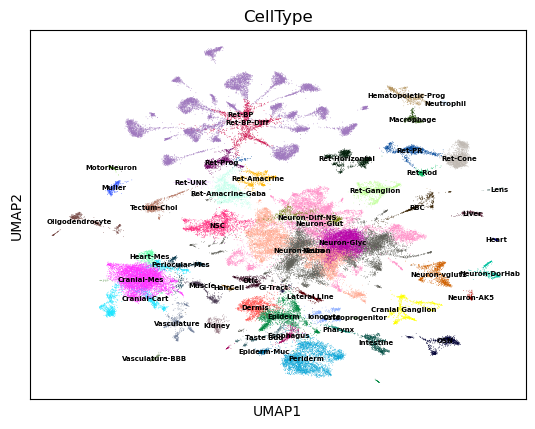

In [14]:
sc.pl.umap(adata, color = ['CellType'], s = 1,legend_loc = 'on data',legend_fontsize=5)

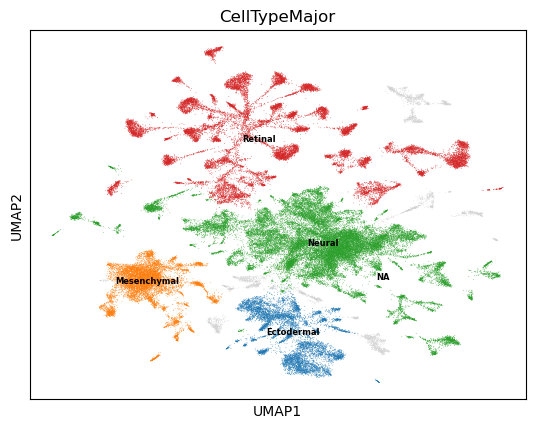

In [15]:
sc.pl.umap(adata, color = ['CellTypeMajor'], s = 1,legend_loc = 'on data',legend_fontsize=6)

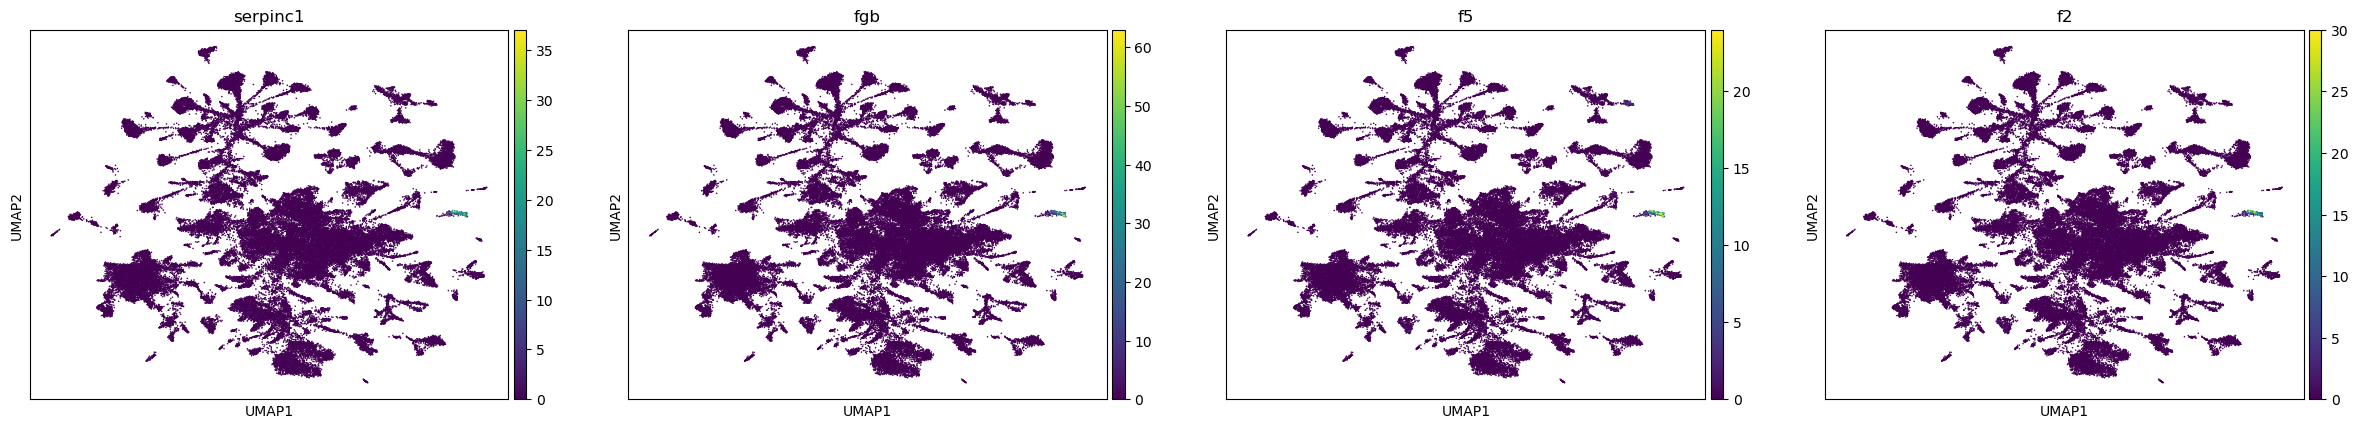

In [16]:
gene_list = ['serpinc1','fgb','f5','f2']
# EXAMPLE
#gene_list = ['','','','']
#gene_list = ['','','','','','','','']
sc.pl.umap(adata, color=[i for i in gene_list], color_map='viridis', legend_fontsize=8, legend_loc = 'on data', s = 5)

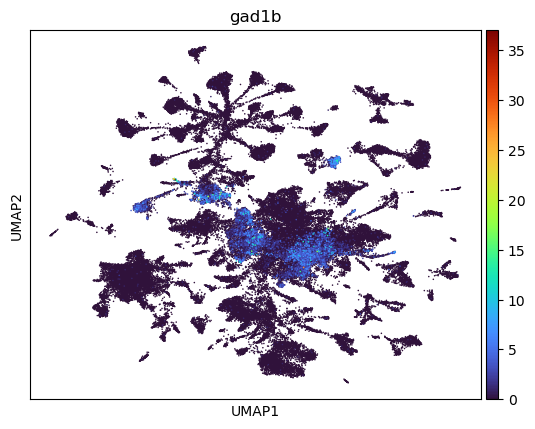

In [17]:
gene_list = ['fga','fgb']
gene_list = ['gad1b']
# EXAMPLE
#gene_list = ['','','','']
#gene_list = ['','','','','','','','']
sc.pl.umap(adata, color=[i for i in gene_list], color_map='turbo', legend_fontsize=8, legend_loc = 'on data', s = 5)

In [18]:
temp = adata.obs['CellType'] == "NSC"
temp = adata.obs.loc[temp, 'genotype']
temp.value_counts()

genotype
Wts    710
R21    577
S2b    434
Wik    375
Name: count, dtype: int64

## Cell cycle

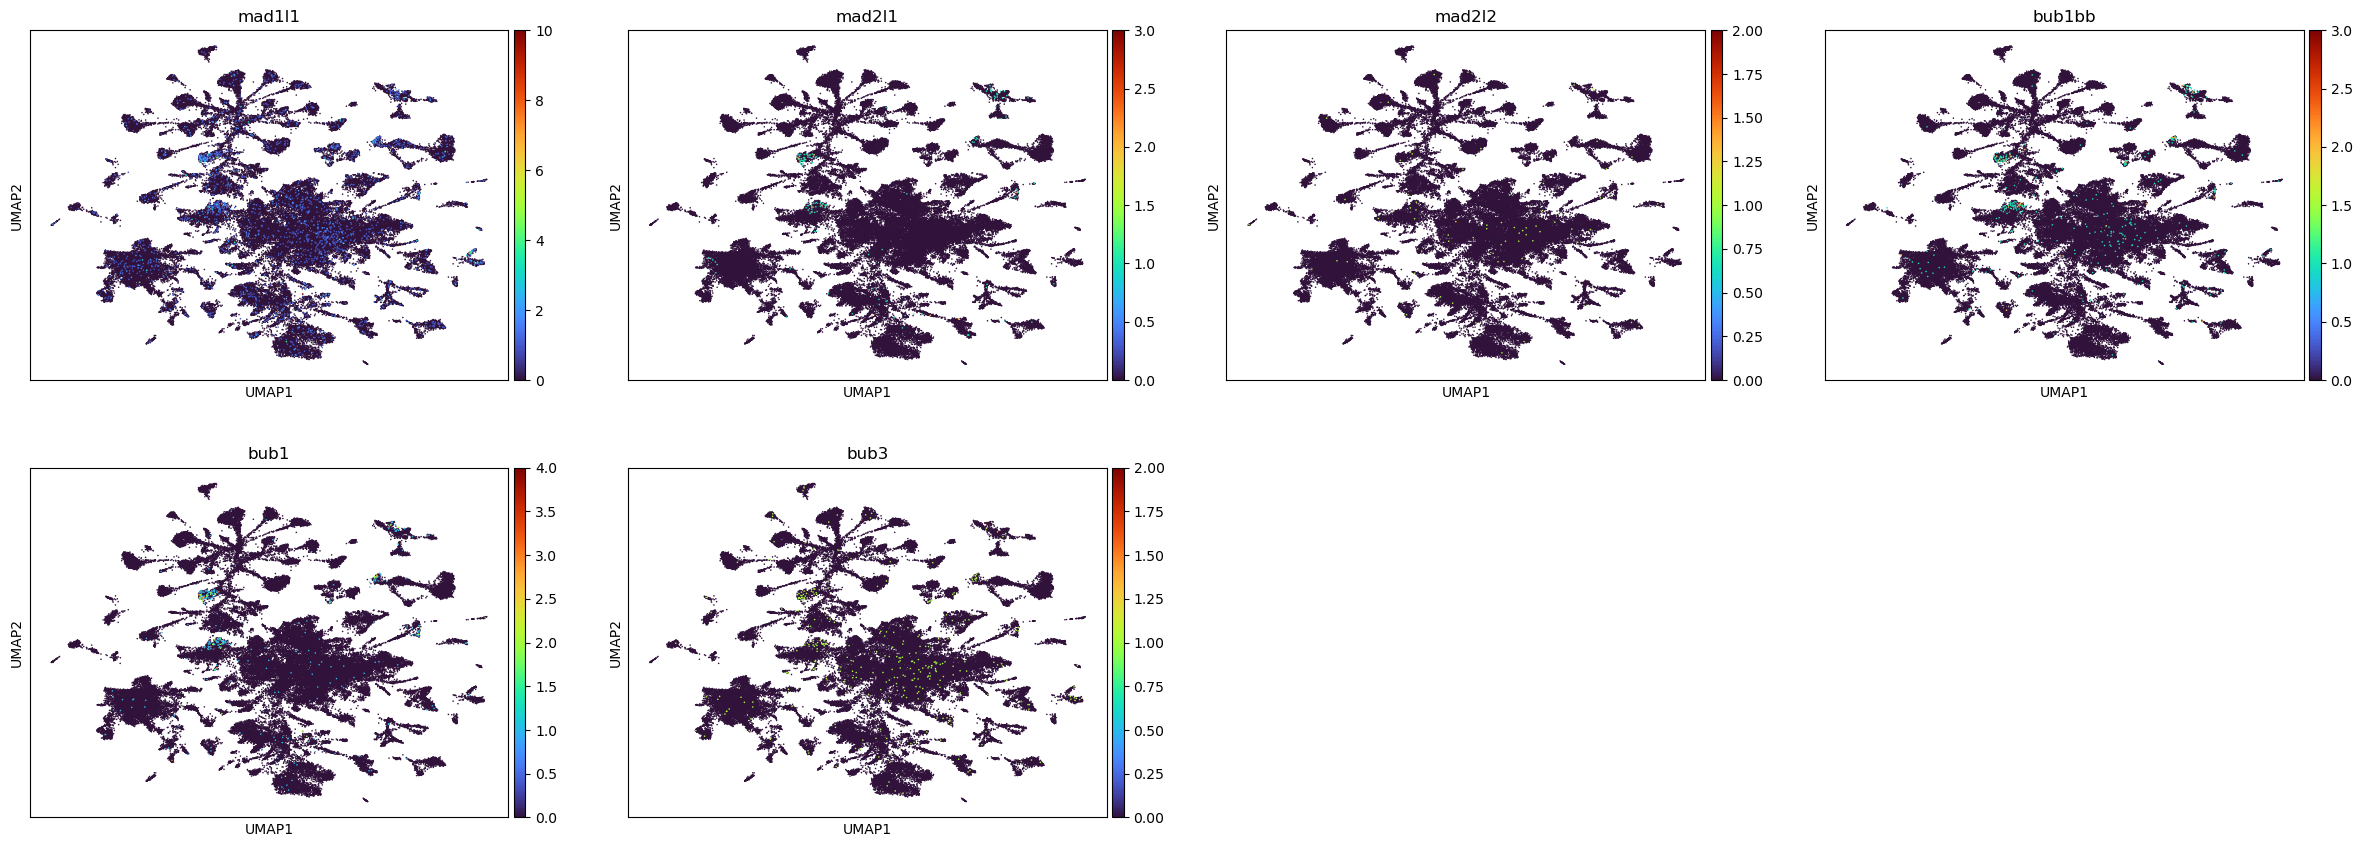

In [19]:
gene_list = ['mad1l1','mad2l1','mad2l2','bub1bb','bub1','bub3']
# EXAMPLE
#gene_list = ['','','','']
#gene_list = ['','','','','','','','']
sc.pl.umap(adata, color=[i for i in gene_list], color_map='turbo', legend_fontsize=8, legend_loc = 'on data', s = 5)

In [20]:
celltypes= ['NSC','Neuron-Diff','Ret-Prog','Cranial-Mes']

In [21]:
cell_cycle_genes = [x.strip() for x in open('regev_lab_cell_cycle_genes.txt')]
cell_cycle_genes = [cell_cycle_genes.lower() for cell_cycle_genes in cell_cycle_genes]
print(cell_cycle_genes[:43])
print(cell_cycle_genes[43:])

['mcm5', 'pcna', 'tyms', 'fen1', 'mcm2', 'mcm4', 'rrm1', 'ung', 'gins2', 'mcm6', 'cdca7', 'dtl', 'prim1', 'uhrf1', 'mlf1ip', 'hells', 'rfc2', 'rpa2', 'nasp', 'rad51ap1', 'gmnn', 'wdr76', 'slbp', 'ccne2', 'ubr7', 'pold3', 'msh2', 'atad2', 'rad51', 'rrm2', 'cdc45', 'cdc6', 'exo1', 'tipin', 'dscc1', 'blm', 'casp8ap2', 'usp1', 'clspn', 'pola1', 'chaf1b', 'brip1', 'e2f8']
['hmgb2', 'cdk1', 'nusap1', 'ube2c', 'birc5', 'tpx2', 'top2a', 'ndc80', 'cks2', 'nuf2', 'cks1b', 'mki67', 'tmpo', 'cenpf', 'tacc3', 'fam64a', 'smc4', 'ccnb2', 'ckap2l', 'ckap2', 'aurkb', 'bub1', 'kif11', 'anp32e', 'tubb4b', 'gtse1', 'kif20b', 'hjurp', 'cdca3', 'hn1', 'cdc20', 'ttk', 'cdc25c', 'kif2c', 'rangap1', 'ncapd2', 'dlgap5', 'cdca2', 'cdca8', 'ect2', 'kif23', 'hmmr', 'aurka', 'psrc1', 'anln', 'lbr', 'ckap5', 'cenpe', 'ctcf', 'nek2', 'g2e3', 'gas2l3', 'cbx5', 'cenpa']


In [22]:
# directly turned caps to lowercase for zebrafish genes then manually switched to a for duplicated genes (**this is a lazy shortcut)
s_genes = ['mcm5', 'pcna', 'tyms', 'fen1', 'mcm2', 'mcm4', 'rrm1', 'unga','ungb', 'gins2', 'mcm6', 'cdca7a','cdca7b','dtl', 'prim1', 'uhrf1', 'hells',
           'rfc2', 'rpa2', 'nasp', 'rad51ap1', 'gmnn', 'wdr76', 'slbp', 'ccne2', 'ubr7', 'pold3', 'msh2', 'atad2', 'rad51', 'rrm2',
           'cdc45', 'cdc6', 'exo1', 'tipin', 'dscc1', 'blm', 'casp8ap2', 'usp1', 'pola1', 'chaf1b', 'brip1', 'e2f8']
           
g2m_genes = ['hmgb2a','hmgb2b', 'cdk1', 'nusap1', 'ube2c', 'birc5a','birc5b', 'tpx2', 'top2a', 'ndc80', 'cks2', 'nuf2', 'cks1b', 'mki67', 'tmpoa','tmpob', 'cenpf',
            'tacc3', 'smc4', 'ccnb2', 'ckap2l', 'aurkb', 'bub1', 'kif11', 'anp32e', 'tubb4b', 'gtse1', 'kif20ba','kif20bb', 'jpt1a', 'cdc20',
            'ttk', 'kif2c', 'rangap1a','rangap1b', 'ncapd2', 'dlgap5', 'cdca8', 'ect2', 'kif23', 'hmmr', 'aurka', 'anln', 'lbr', 'ckap5',
            'cenpe', 'ctcf', 'nek2', 'g2e3', 'gas2l3', 'cbx5']
sc.tl.score_genes_cell_cycle(adata, s_genes = s_genes, g2m_genes = g2m_genes)

phase
G2M    192
G1     134
S      108
Name: count, dtype: int64

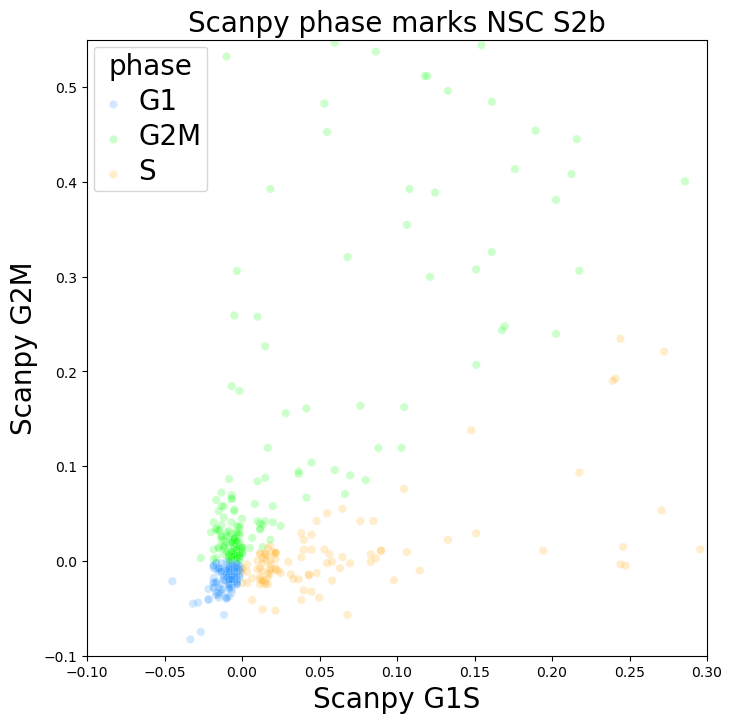

In [23]:
#cell_subset = adata[adata.obs["genotype"] == 'S2b']
cell_subset = adata[(adata.obs['genotype'] == 'S2b') & (adata.obs['CellType'] == 'NSC')]
#sc.tl.score_genes_cell_cycle(cell_subset, s_genes = s_genes, g2m_genes = g2m_genes)
v1 = cell_subset.obs[ 'S_score']
v2 = cell_subset.obs[ 'G2M_score' ]

mask = (v1 + v2 ) > -1
cell_subset = cell_subset[mask]
phase_colors = {
'G1': '#1E90FF',  # Blue
'G2M': '#00FF00', # Green
'S': '#FFA500'   # Orange
}
fig = plt.figure(figsize = (8,8));  c = 0
if 1: # Create Phase plot

    #phase_threshold = 0
    v1 = cell_subset.obs[ 'S_score']
    v2 = cell_subset.obs[ 'G2M_score' ]

    #c += 1; fig.add_subplot(1,n_x_subplots ,c)
    plt.title('Scanpy phase marks NSC S2b', fontsize = 20 )
    v_color =  cell_subset.obs[ 'phase']
    ax = sns.scatterplot(x=v1,y=v2, hue = v_color, palette = phase_colors, alpha =0.2 )
    # Changing fontsize for the legend: 
    plt.setp(ax.get_legend().get_texts(), fontsize=20) # for legend text
    plt.setp(ax.get_legend().get_title(), fontsize=20) # for legend title    
    plt.xlabel('Scanpy G1S' , fontsize = 20)
    plt.ylabel('Scanpy G2M', fontsize = 20 )
    plt.xlim(-0.1,0.30)
    plt.ylim(-0.1,0.55)
cell_subset.obs.phase.value_counts()

phase
G2M    137
G1     129
S      109
Name: count, dtype: int64

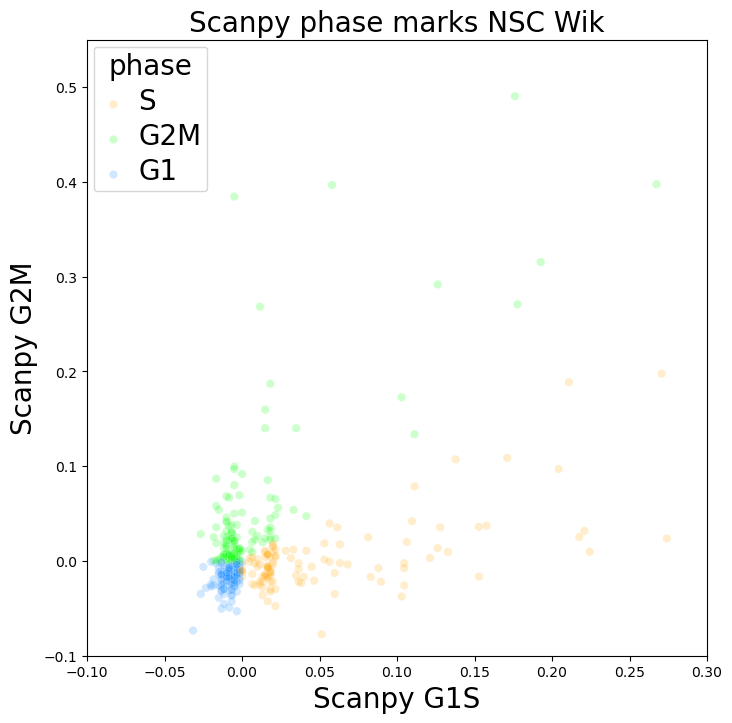

In [24]:
#cell_subset = adata[adata.obs["genotype"] == 'Wik']
cell_subset = adata[(adata.obs['genotype'] == 'Wik') & (adata.obs['CellType'] == 'NSC')]
#sc.tl.score_genes_cell_cycle(cell_subset, s_genes = s_genes, g2m_genes = g2m_genes)
v1 = cell_subset.obs[ 'S_score']
v2 = cell_subset.obs[ 'G2M_score' ]

mask = (v1 + v2 ) > -1
cell_subset = cell_subset[mask]
phase_colors = {
'G1': '#1E90FF',  # Blue
'G2M': '#00FF00', # Green
'S': '#FFA500'   # Orange
}
fig = plt.figure(figsize = (8,8));  c = 0
if 1: # Create Phase plot

    #phase_threshold = 0
    v1 = cell_subset.obs[ 'S_score']
    v2 = cell_subset.obs[ 'G2M_score' ]

    #c += 1; fig.add_subplot(1,n_x_subplots ,c)
    plt.title('Scanpy phase marks NSC Wik', fontsize = 20 )
    v_color =  cell_subset.obs[ 'phase']
    ax = sns.scatterplot(x=v1,y=v2, hue = v_color, palette = phase_colors, alpha =0.2 )
    # Changing fontsize for the legend: 
    plt.setp(ax.get_legend().get_texts(), fontsize=20) # for legend text
    plt.setp(ax.get_legend().get_title(), fontsize=20) # for legend title    
    plt.xlabel('Scanpy G1S' , fontsize = 20)
    plt.ylabel('Scanpy G2M', fontsize = 20 )
    plt.xlim(-0.1,0.30)
    plt.ylim(-0.1,0.55)
cell_subset.obs.phase.value_counts()